In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy.special import chndtrinc, ncfdtrinc
from scipy.stats import f, ncf

In [3]:
N = 100
pvals_range =np.arange(.01, .05, .001)
power = .95
critval = f._ppf(.95, 1, N-2)
ncp = ncfdtrinc(1, N-2, 1-power, critval)
exp_smaller_f_80 = [ncf._sf(f.ppf(1 - pcrit, 1, N-2), 1, N-2, ncp) for pcrit in pvals_range] 

In [4]:
plt.plot(pvals_range[1:], np.diff(exp_smaller_f_33))
plt.plot(pvals_range[1:], np.diff(exp_smaller_f_80))
ax = plt.gca()
# ax.set_xscale("log")
ax.set_xticks([0.01, 0.02, 0.03, 0.04, 0.05], minor=False)
ax.set_xticklabels([".01", ".02", ".03", ".04", ".05"])

NameError: name 'exp_smaller_f_33' is not defined

In [5]:
ax.set_xticks([0.0001, 0.001, 0.01, 0.05, 0.1], minor=False)
ax.set_xticklabels([".0001", ".001", ".01", ".05", ".1"])
ax.set_xticks([], minor=True)

NameError: name 'ax' is not defined

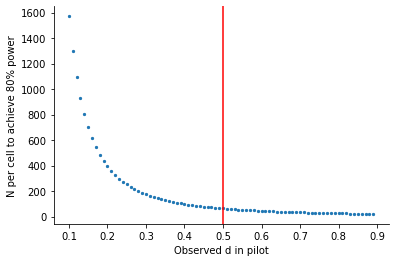

In [6]:
plt.scatter(
    np.arange(0.1, 0.9, 0.01),
    [pg.power_ttest(d=i, power=0.8) for i in np.arange(0.1, 0.9, 0.01)],
    s=5,
)
ax = plt.gca()
ax.set_xlabel("Observed d in pilot")
ax.set_ylabel("N per cell to achieve 80% power")
ax.axvline(0.5, color="red")
sns.despine()
plt.savefig("Fig1.png", dpi=400, bbox_inches="tight")

In [7]:
def simulate_procedure(true_d=0.5, n_pilot=100, power=0.8):
    x = np.random.normal(0, 1, n_pilot)
    y = np.random.normal(0 + true_d, 1, n_pilot)
    obs_d = np.abs(pg.ttest(x, y).loc["T-test", "cohen-d"])
    req_n = pg.power_ttest(d=obs_d, power=power)
    return req_n, pg.power_ttest(n=req_n, d=true_d)

In [11]:
np.random.seed(20391)
N_PILOT = 100
TRUE_D = 0.5

POWER = 0.50
knowns = {}
pilots = {}
POWERS = [0.33, 0.5, 0.80, 0.95]
for POWER in POWERS:
    pvals_range = np.arange(0.01, 0.0501, 0.01)
    req_n, obs_power = np.array(
        [
            simulate_procedure(n_pilot=N_PILOT, power=POWER, true_d=TRUE_D)
            for i in range(N_PILOT)
        ]
    ).T
    req_n = np.round(req_n)
    pilot = np.diff(
        np.array(
            [
                [
                    ncf._sf(
                        f.ppf(1 - pcrit, 1, rn - 2),
                        1,
                        rn - 2,
                        ncfdtrinc(1, rn - 2, 1 - POWER, f._ppf(0.95, 1, rn - 2)),
                    )
                    for pcrit in [0] + pvals_range.tolist()
                ]
                for rn in req_n
            ]
        ),
        axis=1,
    )
    pilots[POWER] = (pilot.T/pilot.sum(axis=1)).T
    N = pg.power_ttest(d=TRUE_D, power=POWER)
    critval = f._ppf(0.95, 1, N - 2)
    ncp = ncfdtrinc(1, N - 2, 1 - POWER, critval)
    known = np.diff(
        [
            ncf._sf(f.ppf(1 - pcrit, 1, N - 2), 1, N - 2, ncp)
            for pcrit in [0] + pvals_range.tolist()
        ]
    )
    knowns[POWER] = known/known.sum()

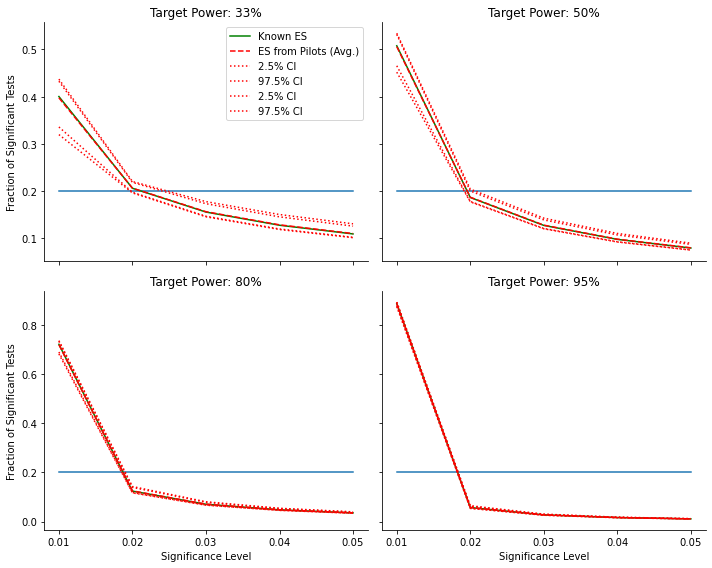

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey="row", facecolor="white")
for p, ax in zip(POWERS, axes.flat):
    known = knowns[p]
    pilot = pilots[p]
    ax.plot([.01, .02, .03, .04, .05], [.2, .2, .2, .2, .2], label="_Null")
    ax.plot(pvals_range, known, label="Known ES", color="green")
    ax.plot(
        pvals_range,
        pilot.mean(axis=0),
        label="ES from Pilots (Avg.)",
        ls="--",
        color="red",
    )
    ax.plot(
        pvals_range,
        np.percentile(pilot, 97.5, axis=0),
        label="2.5% CI",
        ls=":",
        color="red",
    )
    ax.plot(
        pvals_range,
        np.percentile(pilot, 2.5, axis=0),
        label="97.5% CI",
        ls=":",
        color="red",
    )
    ax.plot(
        pvals_range,
        np.min(pilot, axis=0),
        label="2.5% CI",
        ls=":",
        color="red",
    )
    ax.plot(
        pvals_range,
        np.max(pilot, axis=0),
        label="97.5% CI",
        ls=":",
        color="red",
    )
    ax.set_xticks(pvals_range)
    sns.despine(ax=ax)
    ax.set_title(f"Target Power: {p*100:.0f}%")


axes.flat[0].set_ylabel("Fraction of Significant Tests")
axes.flat[2].set_ylabel("Fraction of Significant Tests")
axes.flat[2].set_xlabel("Significance Level")
axes.flat[3].set_xlabel("Significance Level")
axes.flat[0].legend()
plt.tight_layout()
plt.savefig("PCurves.png", dpi=400, bbox_inches="tight")

In [268]:
(pilot.T/pilot.sum(axis=1)).T

array([[0.81327573, 0.08995627, 0.04642235, 0.02954255, 0.0208031 ],
       [0.82141778, 0.08557593, 0.04443205, 0.02844153, 0.02013271],
       [0.81754116, 0.08766117, 0.04538018, 0.02896577, 0.02045172],
       ...,
       [0.8243125 , 0.0840166 , 0.0437273 , 0.02805027, 0.01989333],
       [0.8215129 , 0.08552471, 0.04440888, 0.02842867, 0.02012484],
       [0.82212523, 0.08519494, 0.04425976, 0.02834588, 0.02007419]])

In [269]:
np.diff([f._sf(f.ppf(1-pcrit, 1, N-2), 1, N-2) for pcrit in [0] + pvals_range.tolist()])

array([0.01, 0.01, 0.01, 0.01, 0.01])

In [270]:
knowns[.33]/np.sum(knowns[.33])

array([0.40038363, 0.20624723, 0.15585571, 0.1279684 , 0.10954503])

In [286]:
plt.plot(pvals_range, np.diff(sf_known), label="Known Power")
plt.plot(
    pvals_range,
    np.diff(sf_pilots, axis=1).mean(axis=0),
    label="Mean Power (Pilots)",
    ls="--",
    color="red",
)
plt.plot(
    pvals_range,
    np.percentile(np.diff(sf_pilots, axis=1), 97.5, axis=0),
    label="2.5% CI (Pilots)",
    ls=":",
    color="red",
)
plt.plot(
    pvals_range,
    np.percentile(np.diff(sf_pilots, axis=1), 2.5, axis=0),
    label="97.5% CI (Pilots)",
    ls=":",
    color="red",
)
# plt.plot(pvals_range[1:], np.diff(exp_smaller_exp_obs), label="Predicted from Mean")
plt.legend()
ax = plt.gca()
ax.set_xticks(pvals_range)
# ax.set_yscale("log");

NameError: name 'sf_known' is not defined

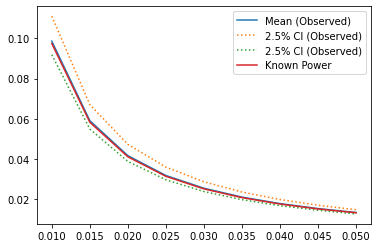

In [166]:
plt.plot(
    pvals_range[1:],
    np.diff(exp_smaller_obs, axis=1).mean(axis=0),
    label="Mean (Observed)",
)
plt.plot(
    pvals_range[1:],
    np.percentile(np.diff(exp_smaller_obs, axis=1), 97.5, axis=0),
    label="2.5% CI (Observed)",
    ls=":",
)
plt.plot(
    pvals_range[1:],
    np.percentile(np.diff(exp_smaller_obs, axis=1), 2.5, axis=0),
    label="2.5% CI (Observed)",
    ls=":",
)
plt.plot(pvals_range[1:], np.diff(exp_smaller_exp), label="Known Power")
# plt.plot(pvals_range[1:], np.diff(exp_smaller_exp_obs), label="Predicted from Mean")
plt.legend()
ax = plt.gca()
# ax.set_xscale("log");

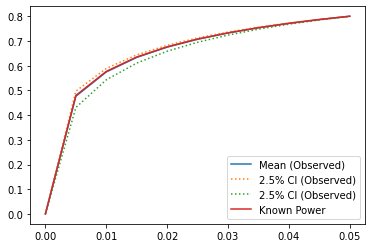

In [187]:
plt.plot(
    [0] + pvals_range.tolist(), exp_smaller_obs.mean(axis=0), label="Mean (Observed)"
)
plt.plot(
    [0] + pvals_range.tolist(),
    np.percentile(exp_smaller_obs, 97.5, axis=0),
    label="2.5% CI (Observed)",
    ls=":",
)
plt.plot(
    [0] + pvals_range.tolist(),
    np.percentile(exp_smaller_obs, 2.5, axis=0),
    label="2.5% CI (Observed)",
    ls=":",
)
plt.plot([0] + pvals_range.tolist(), exp_smaller_exp, label="Known Power")
# plt.plot(pvals_range[1:], np.diff(exp_smaller_exp_obs), label="Predicted from Mean")
plt.legend()
ax = plt.gca()
# ax.set_xscale("log");

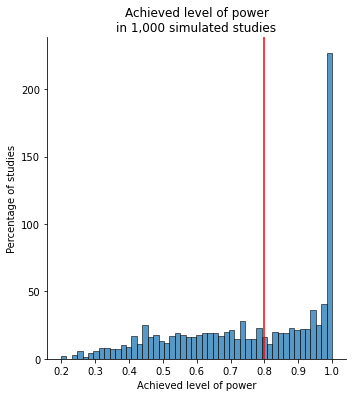

In [138]:
g = sns.displot(obs_power, bins=50)
g.set_xlabels("Achieved level of power")
g.set_ylabels("Percentage of studies")
g.ax.set_title("Achieved level of power\nin 1,000 simulated studies")
g.ax.axvline(0.8, color="red")
plt.savefig("Fig2.png", dpi=400, bbox_inches="tight")

In [126]:
true_power = np.array([simulate_procedure(n_pilot=50) for i in range(1000)])

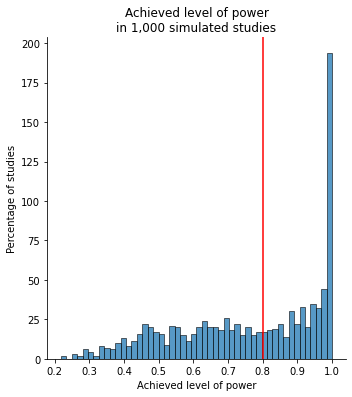

In [127]:
g = sns.displot(true_power, bins=50)
g.set_xlabels("Achieved level of power")
g.set_ylabels("Percentage of studies")
g.ax.set_title("Achieved level of power\nin 1,000 simulated studies")
g.ax.axvline(0.8, color="red")
plt.savefig("Fig3.png", dpi=400, bbox_inches="tight")

In [97]:
np.percentile(obs_d, [2.5, 97.5])

array([0.10672831, 0.90164881])

In [79]:
obs_d, required_n = np.array([simulate_pilot() for i in range(1000)]).T

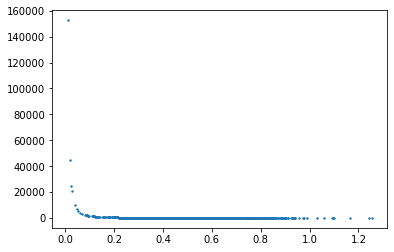

In [69]:
plt.scatter(*required_n, s=2)

In [60]:
np.round(required_n.T, 2)

array([[  0.39, 101.89],
       [  0.93,  18.98],
       [  0.3 , 172.75],
       ...,
       [  0.66,  37.15],
       [  0.34, 134.25],
       [  0.58,  48.  ]])

<AxesSubplot:ylabel='Proportion'>

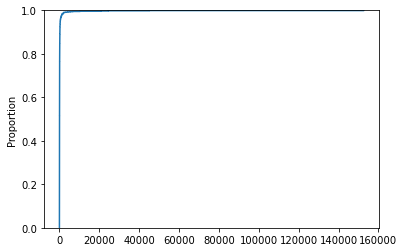

In [73]:
sns.ecdfplot(np.round(required_n, 2)[1])